# Landing Page A/B Test Analysis — Conversion & Revenue Optimization
### Data Analysis Project with Python, Pandas & Statistical Hypothesis Testing

**Author:** David Anampa

This project evaluates an A/B test run on a landing page to support a data-driven business decision between two page versions, A and B.

## Project Overview

The dataset contains information on users exposed to two landing page versions (A and B) as part of a controlled A/B experiment, including region, device, traffic source, user type, conversion outcome, and spend.

The analysis follows a clear, progressive structure:

1. Explore and validate the data
2. Compare average spend per user between page A and page B
3. Compare the conversion rate between page A and page B
4. Examine the relationship between traffic source and conversion
5. Examine the relationship between user type and conversion
6. Visualize the results to support the conclusions

Appropriate statistical tests are applied at each step to compare the two page versions and recommend which one performs better, with the decision justified by the data.

## 1. Data Loading & Validation

The first stage focuses on importing the dataset and validating its structure, data types, and overall quality before analysis.

In [1]:
# importar librerías
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import levene, ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar el archivo
# load the file
df = pd.read_csv('dataset/landing_experiment.csv')
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [6]:
# información general del dataset
# general dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


### Dataset Description

The dataset contains **40,000 records** and **9 columns**, with no missing values:

- `user_id` — Unique user identifier
- `date` — Date the user was exposed to the page
- `landing` — Page version shown to the user (A or B)
- `region` — User's geographic region
- `dispositivo` — Device type used by the user
- `traffic_source` — Channel through which the user arrived
- `user_type` — User type based on prior history
- `converted` — Whether the user converted
- `gasto` — Amount spent by the user (0 if not converted)

## 2. Column Standardization & Type Correction

Column names were translated and standardized to English, and the `date` column was converted to datetime type for temporal analysis.

In [7]:
# estandarizar los nombres de las columnas
# standardize column names
df = df.rename(columns={
    'landing': 'landing_version',
    'dispositivo': 'device',
    'gasto': 'spend'
})

# convertir date a tipo datetime
# convert date to datetime type
df['date'] = pd.to_datetime(df['date'])

# verificar cambios
# verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          40000 non-null  object        
 1   date             40000 non-null  datetime64[ns]
 2   landing_version  40000 non-null  object        
 3   region           40000 non-null  object        
 4   device           40000 non-null  object        
 5   traffic_source   40000 non-null  object        
 6   user_type        40000 non-null  object        
 7   converted        40000 non-null  int64         
 8   spend            40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


## 3. Exploratory Data Analysis & Quality Check

Each key variable of the experiment is validated to confirm it is well defined, complete, and consistent before running any statistical test.

In [8]:
# verificar usuarios únicos
# verify unique users
df['user_id'].nunique()

40000

In [9]:
# identificar el rango temporal del experimento
# identify the experiment's date range
print("Min date:", df['date'].min())
print("Max date:", df['date'].max())

Min date: 2026-01-01 00:00:00
Max date: 2026-01-28 00:00:00


In [10]:
# resumen estadístico de spend
# descriptive statistics for spend
df['spend'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: spend, dtype: float64

In [11]:
# resumen estadístico de converted
# descriptive statistics for converted
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

In [12]:
# explorar variables categóricas y su distribución
# explore categorical variables and their distribution
categorical_cols = ['landing_version', 'region', 'device', 'traffic_source', 'user_type']

for col in categorical_cols:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-" * 40)

landing_version:
landing_version
B    20018
A    19982
Name: count, dtype: int64
----------------------------------------
region:
region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: count, dtype: int64
----------------------------------------
device:
device
Mobile     24829
Desktop    15171
Name: count, dtype: int64
----------------------------------------
traffic_source:
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64
----------------------------------------
user_type:
user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64
----------------------------------------


**Data quality diagnosis**

- The dataset contains 40,000 records across 9 variables with no missing values, so no missing-data treatment is required.
- Most variables are categorical, `converted` is binary, and `spend` is numeric.
- Categorical variables show consistent categories with no unexpected or misspelled values. The A/B split is close to balanced, which supports a fair comparison between versions.
- `converted` only contains the expected values (0 and 1), and `spend` has no negative values; zero amounts are consistent with users who did not convert. The `date` column spans 28 distinct dates with no inconsistencies.
- No further cleaning is required beyond the `date` type conversion already applied.

## 4. Average Spend Comparison — Page A vs. Page B

This section evaluates whether there is a statistically significant difference in average spend between converted users on page A and page B, in order to identify which version generates greater economic value.

**Hypotheses**
- **H₀:** the average spend of converted users is equal for versions A and B.
- **H₁:** the average spend of converted users differs between versions A and B.

In [13]:
# gasto por versión (solo usuarios convertidos)
# spend by version (converted users only)
spend_a = df[(df['landing_version'] == 'A') & (df['converted'] == 1)]['spend']
spend_b = df[(df['landing_version'] == 'B') & (df['converted'] == 1)]['spend']

print("Converted users per page (A, B):", len(spend_a), len(spend_b))

Converted users per page (A, B): 2512 3194


In [14]:
# prueba de Levene para igualdad de varianzas
# Levene's test for equality of variances
stat, p_value = levene(spend_a, spend_b)
print(f"Statistic: {stat}")
print(f"P-value: {p_value}")

Statistic: 29.17646453202917
P-value: 6.875301988016253e-08


In [15]:
# prueba t de Welch (varianzas no asumidas iguales)
# Welch's t-test (unequal variances assumed)
statistic, p_value = ttest_ind(spend_a, spend_b, equal_var=False)
print(f"Statistic: {statistic}")
print(f"P-value: {p_value}")

Statistic: -9.48101092267275
P-value: 3.627602231521493e-21


### Conclusion & Interpretation

**Decision:** the null hypothesis is rejected. Levene's test indicates the variances of the two groups differ (p < 0.05), so Welch's t-test was used; it also returns a p-value below 0.05, providing evidence of a statistically significant difference in average spend between versions A and B.

**Business interpretation:** the average spend of converted users differs between versions A and B, with version B showing a higher average spend. This suggests version B is associated with greater spend per converted user, though this should be read as an observed difference in the data rather than a causal relationship.

## 5. Conversion Rate Comparison — Page A vs. Page B

This section evaluates whether there is a statistically significant difference in conversion rate between page A and page B, in order to identify which version generates more converted users.

**Hypotheses**
- **H₀:** the conversion rate is equal for pages A and B.
- **H₁:** the conversion rate differs between pages A and B.

In [16]:
# usuarios convertidos y totales por página
# converted and total users by page
converted = df.groupby('landing_version')['converted'].sum()
total = df.groupby('landing_version')['converted'].count()

print("Converted users by page:\n", converted)
print("\nTotal users by page:\n", total)

Converted users by page:
 landing_version
A    2512
B    3194
Name: converted, dtype: int64

Total users by page:
 landing_version
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
# prueba z de proporciones
# z-test for proportions
statistic, p_value = proportions_ztest(converted, total)
print(f"Statistic: {statistic}")
print(f"P-value: {p_value}")

Statistic: -9.677362674655983
P-value: 3.7629765627523803e-22


In [18]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: there is evidence of a difference in conversion rate.")
else:
    print("Fail to reject the null hypothesis: not enough evidence of a difference in conversion rate.")

# calcular la tasa de conversión por página
# calculate the conversion rate per page
rate_a = converted['A'] / total['A']
rate_b = converted['B'] / total['B']

print(f"\nConversion rate — Page A: {rate_a:.2%}")
print(f"Conversion rate — Page B: {rate_b:.2%}")
print(f"Absolute difference: {(rate_b - rate_a):.2%}")

Reject the null hypothesis: there is evidence of a difference in conversion rate.

Conversion rate — Page A: 12.57%
Conversion rate — Page B: 15.96%
Absolute difference: 3.38%


### Conclusion & Interpretation

**Decision:** the null hypothesis is rejected. The z-test for proportions returns a p-value below 0.05, providing evidence of a statistically significant difference in conversion rate between pages A and B.

**Business interpretation:** page B recorded a higher conversion rate than page A (15.96% vs. 12.57%), an observed difference of 3.38 percentage points. This supports version B achieving a higher share of converted users in the analyzed data, though the result should be interpreted as an observed difference in the experiment rather than evidence of a causal effect.

## 6. Traffic Source vs. Conversion

This section evaluates whether there is a statistically significant association between `traffic_source` and `converted`, to identify which channels drive more conversions.

**Hypotheses**
- **H₀:** there is no statistically significant association between traffic source and conversion; conversion is independent of traffic source.
- **H₁:** there is a statistically significant association between traffic source and conversion; conversion depends on traffic source.

In [19]:
# tabla de contingencia
# contingency table
traffic_source_table = pd.crosstab(df['traffic_source'], df['converted'])
traffic_source_table

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [20]:
# prueba chi-cuadrado
# chi-square test
chi2, p_value, dof, expected = chi2_contingency(traffic_source_table)

print(f"Chi-square: {chi2}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: there is evidence of association between the variables.")
else:
    print("Fail to reject the null hypothesis: not enough evidence of association between the variables.")

Chi-square: 8.662108841397938
P-value: 0.03413759478339137
Reject the null hypothesis: there is evidence of association between the variables.


In [21]:
# tasa de conversión por canal
# conversion rate by channel
conversion_by_channel = df.groupby('traffic_source')['converted'].mean().sort_values(ascending=False)
print((conversion_by_channel * 100).round(2).astype(str) + '%')

traffic_source
Email       14.99%
Ads         14.74%
Referral    13.88%
Organic     13.79%
Name: converted, dtype: object


### Conclusion & Interpretation

**Decision:** the null hypothesis is rejected. The chi-square test returns a p-value below 0.05, providing evidence of a statistically significant association between traffic source and conversion.

**Business interpretation:** conversion rate varies by traffic source. Email shows the highest conversion rate (14.99%), followed by Ads (14.74%), while Referral (13.88%) and Organic (13.79%) are slightly lower. Although the statistical test indicates an association between the two variables, the observed differences in conversion rates are relatively small — the data suggests traffic source is related to conversion, but does not support concluding that any single channel is substantially superior to the others.

## 7. User Type vs. Conversion

This section evaluates whether there is a statistically significant association between `user_type` and `converted`, keeping in mind that a returning user may have visited before without necessarily converting on this occasion. The goal is to identify which profiles show a higher likelihood of conversion.

**Hypotheses**
- **H₀:** there is no statistically significant association between user type and conversion; conversion is independent of user type.
- **H₁:** there is a statistically significant association between user type and conversion; conversion depends on user type.

In [22]:
# tabla de contingencia
# contingency table
user_type_table = pd.crosstab(df['user_type'], df['converted'])
user_type_table

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [23]:
# prueba chi-cuadrado
# chi-square test
chi2, p_value, dof, expected = chi2_contingency(user_type_table)

print(f"Chi-square: {chi2}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: there is evidence of association between the variables.")
else:
    print("Fail to reject the null hypothesis: not enough evidence of association between the variables.")

Chi-square: 0.5134849494478645
P-value: 0.4736341272301974
Fail to reject the null hypothesis: not enough evidence of association between the variables.


In [24]:
# tasa de conversión por tipo de usuario
# conversion rate by user type
conversion_by_user_type = df.groupby('user_type')['converted'].mean().sort_values(ascending=False)
print((conversion_by_user_type * 100).round(2).astype(str) + '%')

user_type
Nuevo         14.36%
Recurrente    14.09%
Name: converted, dtype: object


### Conclusion & Interpretation

**Decision:** the null hypothesis is not rejected. The chi-square test returns a p-value above 0.05, so there is not enough statistically significant evidence of an association between user type and conversion.

**Business interpretation:** conversion rates are very similar between new users (14.36%) and returning users (14.09%). The data does not provide sufficient evidence to claim that user type is associated with differences in conversion; both groups show comparable conversion behavior within the sample.

## 8. Visualization of Categorical Relationships

The relationship between the categorical variables (`traffic_source`, `user_type`) and conversion is visualized, showing both the absolute count of converted/non-converted users and the relative conversion rate per category. This reinforces the results obtained in the statistical tests.

### Traffic Source vs. Conversion

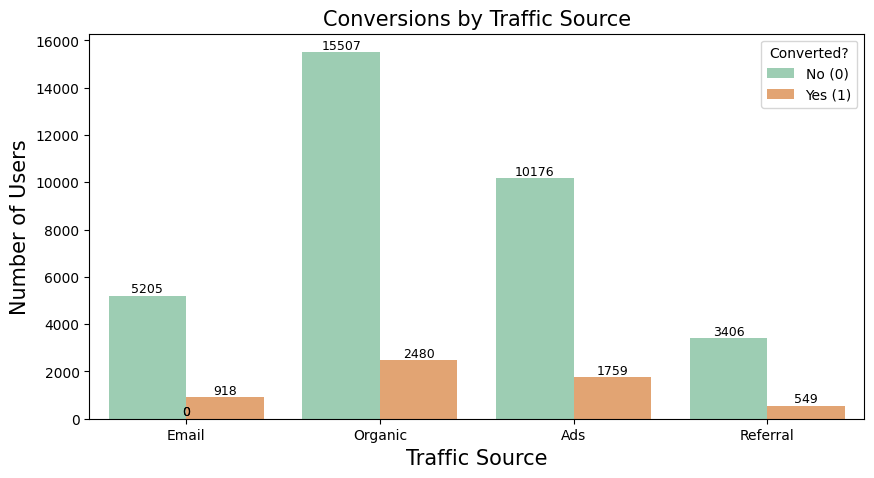

In [25]:
# gráfico de barras agrupadas
# grouped bar chart
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"])

plt.title('Conversions by Traffic Source', fontsize=15)
plt.xlabel('Traffic Source', fontsize=15)
plt.ylabel('Number of Users', fontsize=15)
plt.legend(title='Converted?', labels=['No (0)', 'Yes (1)'])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9)

plt.show()

**Comment:** conversions vary across traffic sources. While some channels record a higher absolute number of converted users, these differences should be interpreted alongside the total volume of users from each source.

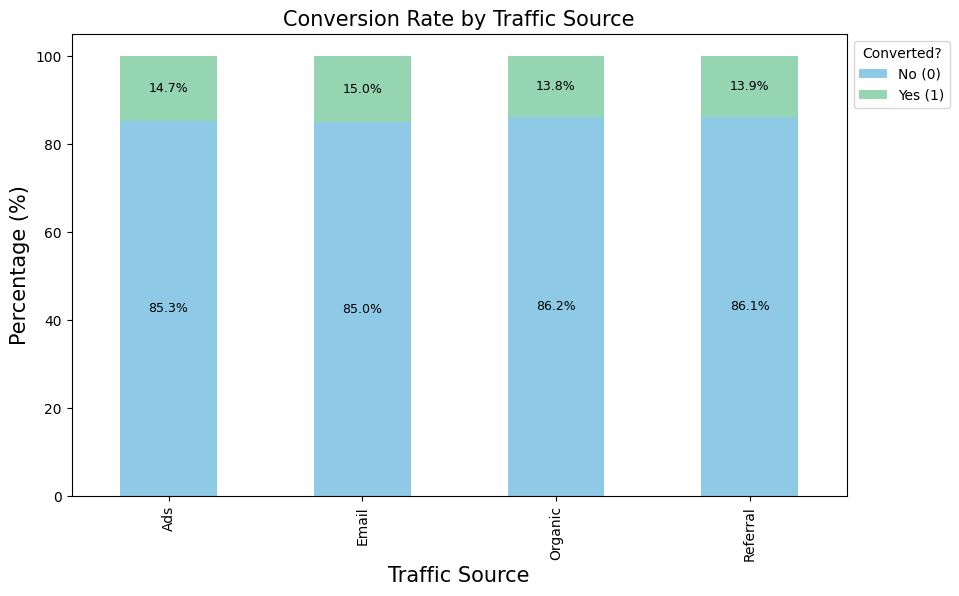

In [26]:
# normalizar la tabla
# normalize the table
normalized_traffic_source = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

# gráfico de barras apiladas
# stacked bar chart
ax = normalized_traffic_source.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Conversion Rate by Traffic Source', fontsize=15)
plt.ylabel('Percentage (%)', fontsize=15)
plt.xlabel('Traffic Source', fontsize=15)
plt.legend(title='Converted?', labels=['No (0)', 'Yes (1)'], loc='upper left', bbox_to_anchor=(1, 1))

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    if height > 3:
        ax.annotate(f'{height:.1f}%', (p.get_x() + width / 2, p.get_y() + height / 2), ha='center', va='center', fontsize=9)

plt.show()

**Comment:** conversion rates differ across traffic sources. Email records the highest share of conversions, followed by Ads, while Referral and Organic show slightly lower percentages, consistent with the chi-square test results.

### User Type vs. Conversion

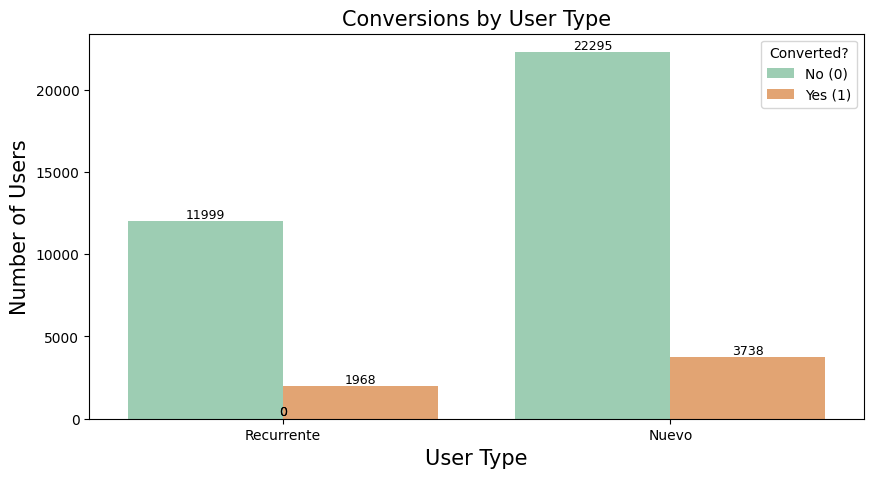

In [27]:
# gráfico de barras agrupadas
# grouped bar chart
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])

plt.title('Conversions by User Type', fontsize=15)
plt.xlabel('User Type', fontsize=15)
plt.ylabel('Number of Users', fontsize=15)
plt.legend(title='Converted?', labels=['No (0)', 'Yes (1)'])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9)

plt.show()

**Comment:** conversion distribution is similar between new and returning users. Differences in absolute counts mainly reflect the relative size of each group within the sample.

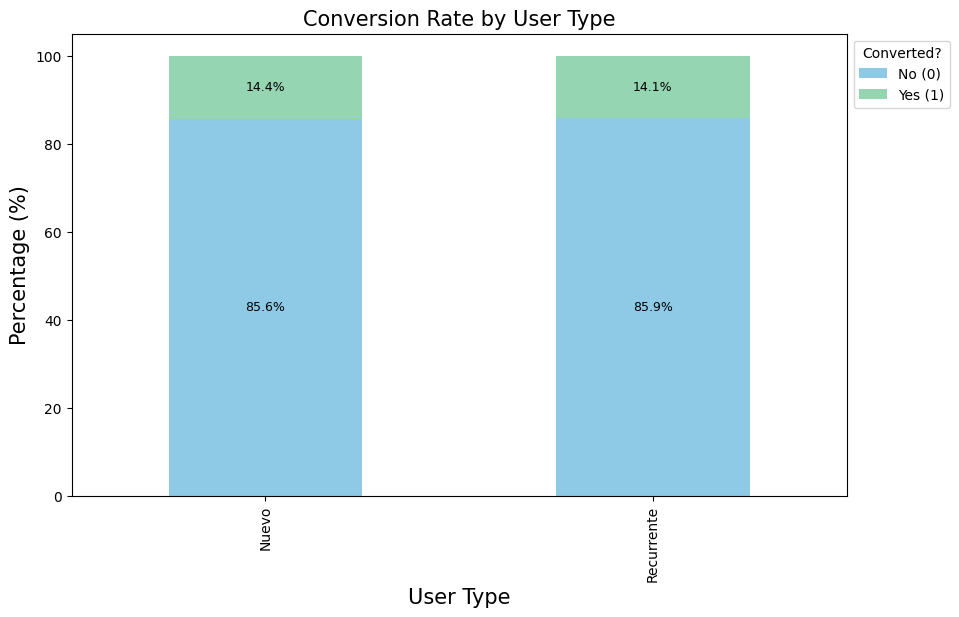

In [28]:
# normalizar la tabla
# normalize the table
normalized_user_type = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

# gráfico de barras apiladas
# stacked bar chart
ax = normalized_user_type.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Conversion Rate by User Type', fontsize=15)
plt.ylabel('Percentage (%)', fontsize=15)
plt.xlabel('User Type', fontsize=15)
plt.legend(title='Converted?', labels=['No (0)', 'Yes (1)'], loc='upper left', bbox_to_anchor=(1, 1))

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    if height > 3:
        ax.annotate(f'{height:.1f}%', (p.get_x() + width / 2, p.get_y() + height / 2), ha='center', va='center', fontsize=9)

plt.show()

**Comment:** conversion rates for new and returning users are very similar. This visualization supports the chi-square test result, which found no statistically significant association between user type and conversion.

## 9. Executive Insight for Stakeholders

The findings from the A/B test are translated into actionable business conclusions, focused on page version, conversion, average spend, traffic channels, and user type.

**Questions addressed**
- Which page drives higher conversion and average spend?
- Which traffic channels are most effective at generating conversions?
- Are there significant differences by user type?
- What recommendations can guide marketing strategy?

### Executive Insight — A/B Experiment

**Page comparison (A vs. B)**

*Average spend per converted user:*
- A statistically significant difference was found in average spend between versions A and B.
- Version B recorded a higher average spend among converted users.
- **Interpretation:** in the analyzed data, version B was associated with higher average spend per converted user.

*Conversion rate:*
- Version B reached a 15.96% conversion rate, compared to 12.57% for version A — a statistically significant difference of 3.39 percentage points.
- **Interpretation:** in the sample analyzed, version B produced a higher share of converted users than version A.

**Segmentation by traffic source**
- A statistically significant association was found between traffic source and conversion. Email recorded the highest conversion rate (14.99%), followed by Ads (14.74%), while Referral and Organic were slightly lower.
- **Interpretation:** conversion rates differ across the traffic sources analyzed; however, the observed differences are relatively small and should be evaluated alongside other performance indicators such as user volume and acquisition cost.

**Segmentation by user type**
- No statistically significant association was found between user type and conversion. Observed rates were similar for new (14.36%) and returning users (14.09%).
- **Interpretation:** in the sample analyzed, no relevant differences in conversion rate were observed between the two user types.

**Business recommendations**
- Consider version B as the primary candidate for broader rollout or further evaluation, as it showed a higher conversion rate and higher average spend per converted user in the analyzed data.
- Continue monitoring the Email and Ads channels, which recorded the highest conversion rates, complementing the analysis with metrics such as traffic volume, acquisition cost, and return on investment before prioritizing further investment.
- Since no statistically significant differences were found between new and returning users, the available evidence does not support a strategy differentiated solely by user type.

# Executive Summary

## Objective
This project evaluates an A/B test on a landing page to determine which version — A or B — performs better in terms of conversion rate and average spend, and to identify which traffic sources and user segments are most associated with conversion.

## Methodology
The workflow included data validation, column standardization, exploratory analysis, and hypothesis testing appropriate to each comparison: Levene's test and Welch's t-test for average spend, a z-test for proportions for conversion rate, and chi-square tests for the categorical associations with traffic source and user type.

## Main Findings
- Version B outperformed version A on both metrics: a higher conversion rate (15.96% vs. 12.57%) and higher average spend per converted user, both statistically significant.
- Traffic source shows a statistically significant, though modest, association with conversion — Email and Ads perform best.
- User type shows no statistically significant association with conversion.

## Business Recommendations
- Prioritize version B for a broader rollout, supported by consistent gains in both conversion and spend.
- Keep investing in Email and Ads as the strongest-performing channels, while validating with volume and cost metrics.
- Avoid differentiating strategy by user type alone, since new and returning users convert at comparable rates.